<div><center><img src="https://ml.ucv.ai/logo.png\" width=150"/> </center></div>


# Proyecto: Recomendación de Anime basado en los gustos del usuario

## Aprendizaje Automático [UCV]


* Alumnos:
    * Thibisay Palma
    * Gabriel Valero
----



In [7]:
#@title Dependencias
import kagglehub, pandas as pd, os
import numpy
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import silhouette_score
import joblib
from rich.console import Console
from rich.table import Table
from rich.panel import Panel
from rich.style import Style
from tabulate import tabulate
from datetime import datetime
from transformers import pipeline, AutoTokenizer, AutoModelForSeq2SeqLM

c:\Users\DELL\Documents\ML\Proyecto\env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Dataset Animes

## Cargar Datos

### Si estás en colab

**Dataset de Animes**

In [8]:
path = kagglehub.dataset_download("svanoo/myanimelist-dataset")
#Seleccionando el archivo con los animes
anime_dataset = pd.read_csv(f"{path}/anime.csv", sep = '\t',on_bad_lines='skip')


## EDA: Análisis Exploratorio de Datos


### Diccionario de Datos: Anime Dataset

| Columna | Descripción |
| :--- | :--- |
| **anime_id** | El ID del anime |
| **anime_url** | La URL de MyAnimeList del anime |
| **title** | El nombre del anime |
| **synopsis** | Breve descripción de la trama del anime |
| **main_pic** | URL a la imagen de portada del anime |
| **type** | Tipo de anime (ejemplo: TV, Película, OVA, etc.) |
| **source_type** | Tipo de material original del anime (ejemplo: Manga, Novela Ligera, etc.) |
| **num_episodes** | Número de episodios en el anime |
| **status** | El estado actual del anime (Emisión finalizada, En emisión o Aún no emitido) |
| **start_date** | Fecha de inicio del anime |
| **end_date** | Fecha de finalización del anime |
| **season** | Temporada en la que el anime comenzó a emitirse (ejemplo: los animes que comenzaron en enero de 2020 tienen como temporada Invierno 2020) |
| **studios** | Lista de estudios que crearon el anime |
| **genres** | Lista de los géneros del anime (Acción, Shonen, etc.) |
| **score** | Puntuación promedio del anime en MyAnimeList |
| **score_count** | Número de usuarios que calificaron el anime |
| **score_rank** | Posición del anime basada en su puntuación en MyAnimeList |
| **popularity_rank** | Posición del anime basada en su popularidad en MyAnimeList |
| **members_count** | Número de usuarios que son miembros del anime |
| **favorites_count** | Número de usuarios que tienen el anime como favorito |
| **watching_count** | Número de usuarios viendo el anime |
| **completed_count** | Número de usuarios que han completado el anime |
| **on_hold_count** | Número de usuarios que tienen el anime en pausa |
| **dropped_count** | Número de usuarios que han abandonado el anime |
| **plan_to_watch_count** | Número de usuarios que planean ver el anime |
| **total_count** | Número total de usuarios que han completado, planean ver, están viendo, han abandonado o tienen el anime en pausa |
| **score_10_count** | Número de usuarios que calificaron el anime con un 10 |
| **score_09_count** | Número de usuarios que calificaron el anime con un 9 |
| **score_08_count** | Número de usuarios que calificaron el anime con un 8 |
| **score_07_count** | Número de usuarios que calificaron el anime con un 7 |
| **score_06_count** | Número de usuarios que calificaron el anime con un 6 |
| **score_05_count** | Número de usuarios que calificaron el anime con un 5 |
| **score_04_count** | Número de usuarios que calificaron el anime con un 4 |
| **score_03_count** | Número de usuarios que calificaron el anime con un 3 |
| **score_02_count** | Número de usuarios que calificaron el anime con un 2 |
| **score_01_count** | Número de usuarios que calificaron el anime con un 1 |
| **clubs** | Lista de clubes de MAL de los que el anime forma parte |
| **pics** | Lista de URLs a imágenes del anime |

### -----

**Visualización**

In [9]:
anime_dataset.iloc[:, 0:20].head()

,anime_id,anime_url,title,synopsis,main_pic,type,source_type,num_episodes,status,start_date,end_date,season,studios,genres,score,score_count,score_rank,popularity_rank,members_count,favorites_count
0,2366,https://myanimelist.net/anime/2366/Touma_Kishi...,Touma Kishinden Oni,Shuramaru is hated and feared by the villagers...,https://cdn.myanimelist.net/images/anime/9/829...,TV,Game,25.0,Finished Airing,1995-10-05 00:00:00,1996-03-21 00:00:00,Fall 1995,J.C.Staff,Supernatural,NaN,NaN,NaN,11743,884,0
1,4940,https://myanimelist.net/anime/4940/Sabaku_no_K...,Sabaku no Kaizoku! Captain Kuppa,"Sometime in the future, the world was complete...",https://cdn.myanimelist.net/images/anime/9/736...,TV,Manga,26.0,Finished Airing,2001-08-13 00:00:00,2002-02-11 00:00:00,Summer 2001,NaN,Action|Adventure,NaN,NaN,NaN,13321,491,2
2,50285,https://myanimelist.net/anime/50285/On_Air_Dek...,On Air Dekinai!,"Set in 2014, the anime follows the adventures ...",https://cdn.myanimelist.net/images/anime/1021/...,TV,Manga,12.0,Currently Airing,2022-01-10 00:00:00,2022-03-28 00:00:00,Winter 2022,Space Neko Company|Jinnan Studio,Comedy,NaN,NaN,NaN,9603,2057,8
3,3975,https://myanimelist.net/anime/3975/Uchi_no_3_S...,Uchi no 3 Shimai,The daily life of the Motsumoto family. The th...,https://cdn.myanimelist.net/images/anime/1631/...,TV,Other,102.0,Finished Airing,2008-04-08 00:00:00,2010-03-30 00:00:00,Spring 2008,Toei Animation|Daewon Media,Comedy|Slice of Life,NaN,NaN,NaN,12740,615,3
4,36036,https://myanimelist.net/anime/36036/Running_Man,Running Man,"The Soul Tree, the great source of our race. ...",https://cdn.myanimelist.net/images/anime/1325/...,TV,Other,48.0,Finished Airing,2017-07-29 00:00:00,2018-10-12 00:00:00,Summer 2017,NaN,Action|Adventure|Kids,NaN,NaN,NaN,17330,155,6


In [10]:
anime_dataset.iloc[:, 20:38].head()

,watching_count,completed_count,on_hold_count,dropped_count,plan_to_watch_count,total_count,score_10_count,score_09_count,score_08_count,score_07_count,score_06_count,score_05_count,score_04_count,score_03_count,score_02_count,score_01_count,clubs,pics
0,61,173,31,75,544,884,0,0,0,0,0,0,0,0,0,0,14045|10778|342,https://cdn.myanimelist.net/images/anime/9/544...
1,26,124,18,73,250,491,0,0,0,0,0,0,0,0,0,0,8494,https://cdn.myanimelist.net/images/anime/9/736...
2,203,0,39,88,1725,2055,0,0,0,0,0,0,0,0,0,0,27907|8652,https://cdn.myanimelist.net/images/anime/1021/...
3,45,163,32,112,263,615,0,0,0,0,0,0,0,0,0,0,69895,https://cdn.myanimelist.net/images/anime/3/716...
4,23,47,6,35,44,155,0,0,0,0,0,0,0,0,0,0,41909,https://cdn.myanimelist.net/images/anime/1325/...


**Estructura y Tipos de Datos**

In [11]:
print("="*50)
print("Dimensiones del dataset")
print("="*50)
print(anime_dataset.shape)

Dimensiones del dataset
(13379, 38)


In [12]:
print("="*50)
print("Información del dataset")
print("="*50)
print(anime_dataset.info())

Información del dataset
<class 'pandas.DataFrame'>
RangeIndex: 13379 entries, 0 to 13378
Data columns (total 38 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   anime_id             13379 non-null  int64  
 1   anime_url            13379 non-null  str    
 2   title                13379 non-null  str    
 3   synopsis             13375 non-null  str    
 4   main_pic             13379 non-null  str    
 5   type                 13379 non-null  str    
 6   source_type          13379 non-null  str    
 7   num_episodes         12948 non-null  float64
 8   status               13379 non-null  str    
 9   start_date           13198 non-null  str    
 10  end_date             12799 non-null  str    
 11  season               4280 non-null   str    
 12  studios              10343 non-null  str    
 13  genres               13379 non-null  str    
 14  score                10714 non-null  float64
 15  score_count          10

**Búsqueda de valores nulos**

In [13]:
print("="*50)
print("Valores nulos")
print("="*50)
print(anime_dataset.isnull().sum())

Valores nulos
anime_id                  0
anime_url                 0
title                     0
synopsis                  4
main_pic                  0
type                      0
source_type               0
num_episodes            431
status                    0
start_date              181
end_date                580
season                 9099
studios                3036
genres                    0
score                  2665
score_count            2665
score_rank             3914
popularity_rank           0
members_count             0
favorites_count           0
watching_count            0
completed_count           0
on_hold_count             0
dropped_count             0
plan_to_watch_count       0
total_count               0
score_10_count            0
score_09_count            0
score_08_count            0
score_07_count            0
score_06_count            0
score_05_count            0
score_04_count            0
score_03_count            0
score_02_count            0
score_

**Búsqueda de duplicados**

In [14]:
print("="*50)
print("Duplicados")
print("="*50)
print("Filas dublicadas: " + str(anime_dataset.duplicated().sum()))

Duplicados
Filas dublicadas: 0


**Análisis de variables categóricas**

In [15]:
print("="*50)
print("Columna: type")
print("="*50)
print(anime_dataset['type'].value_counts())

Columna: type
type
TV         4390
OVA        2848
Movie      2368
ONA        1990
Special    1783
Name: count, dtype: int64


In [16]:
print("="*50)
print("Columna: generes - Cantidad de cada genero")
print("="*50)
print(anime_dataset['genres'].value_counts())

Columna: generes - Cantidad de cada genero
genres
Hentai                                                              895
Comedy                                                              519
Kids                                                                394
Comedy|Slice of Life                                                243
Slice of Life                                                       196
                                                                   ... 
Drama|Horror|Supernatural|Josei                                       1
Action|Adventure|Comedy|Drama|Fantasy|Romance|Ecchi|Harem|School      1
Comedy|Sci-Fi|Ecchi|Harem|Seinen                                      1
Action|Comedy|Sci-Fi|Historical|Mecha|Parody|Samurai|Shounen          1
Action|Comedy|Fantasy|Sports|Martial Arts|Shounen                     1
Name: count, Length: 3542, dtype: int64


In [17]:
print("="*50)
print("Visualización de Columna generos")
print("="*50)
print(anime_dataset['genres'])

Visualización de Columna generos
0                           Supernatural
1                       Action|Adventure
2                                 Comedy
3                   Comedy|Slice of Life
4                  Action|Adventure|Kids
                      ...               
13374                    Sci-Fi|Suspense
13375                              Ecchi
13376        Comedy|Fantasy|Ecchi|Parody
13377    Adventure|Comedy|Fantasy|Parody
13378        Comedy|Slice of Life|Seinen
Name: genres, Length: 13379, dtype: str


**Análisis de Variable de Texto Libre**

In [18]:
print("="*50)
print("Columna: synopsis")
print("="*50)
campos_vacios = anime_dataset['synopsis'].isnull().sum()
print(f"Campos vacíos: " + str(campos_vacios))

Columna: synopsis
Campos vacíos: 4


**Correlación entre Sinopsis y Puntuación**

In [19]:
df_analisis = anime_dataset[['synopsis', 'popularity_rank', 'score', 'score_rank']].copy()
df_analisis['synopsis_len'] = df_analisis['synopsis'].str.len()
correlacion_resultado = df_analisis[['synopsis_len', 'popularity_rank', 'score', 'score_rank']].corr()
print("="*50)
print("Matriz de Correlación:")
print("="*50)
correlacion_resultado

Matriz de Correlación:


,synopsis_len,popularity_rank,score,score_rank
synopsis_len,1.000000,-0.508092,0.321875,-0.363077
popularity_rank,-0.508092,1.000000,-0.658124,0.696397
score,0.321875,-0.658124,1.000000,-0.959482
score_rank,-0.363077,0.696397,-0.959482,1.000000


**Análisis de sinopsis poco representativos**

In [20]:
print("="*50)
print("Columna: synopsis")
print("="*50)
sinopsys_completas = anime_dataset[anime_dataset['synopsis'].str.len() < 200]['synopsis'].count()

print(f"Cantidad de synopsis con poca información: " + str(sinopsys_completas))

Columna: synopsis
Cantidad de synopsis con poca información: 4868


De esta matriz de correlación podemos llegar a las siguientes conclusiones:
* Tamaño de Sinopsis vs. Popularidad (-0.508): Hay una correlación negativa moderada. Esto indica que los animes más populares tienden a tener descripciones más detalladas.
* Tamaño de Sinopsis vs. Puntuación (0.321): Hay una correlación positiva débil/moderada. Esto quiere decir que aunque hay una tendencia, no es una regla de oro. Hay animes con sinopsis cortas que son obras maestras y otros con testamentos de texto que no son tan buenos.
* Popularidad vs. Puntuación (-0.658): Hay una correlación negativa moderada-fuerte. Se interpreta como, los animes que la gente puntúa alto (score alto) suelen ser los mismos que todo el mundo está viendo (rank bajo).

### Informe de Análisis Exploratorio de Datos (EDA) - Anime Dataset

#### Resumen de Estructura y Dimensiones
El dataset cuenta con un total de **13,379 registros** y **38 columnas**.
* **Tipos de datos:** Existe una mezcla de variables numéricas (20 enteras y 4 de punto flotante) y categóricas/texto (14 objetos).
* **Integridad:** No se detectaron filas duplicadas, lo que asegura que no hay sesgo por repetición de datos.

#### Calidad de los Datos y Valores Faltantes
Se identificaron columnas críticas con valores nulos que requerirán atención en la etapa de preprocesamiento:
* **Sinopsis:** Solo 4 valores nulos. Al ser una variable clave para el análisis que se quiere hacer, estas filas pueden ser eliminadas. Establecimos que la cantidad de caracteres mínimas que debe tener una synopsis para tener suficiente información para ser clasificado es de 200 caracteres y observamos que de los **13,379 registros hay al menos 4,868** que no tienen información suficiente para poder ser clasificados.

* **Score y Score Rank:** Presentan un alto índice de nulos (~20% y ~29% respectivamente). Deberemos decidir si eliminar los animes sin puntuación o tratarlos como un segmento aparte.
* **Season:** Es la columna con más faltantes (~68%). Dado que no aporta suficiente información, se puede eliminar.

#### Las variables
**total_count,score_10_count, score_09_count, score_08_count, score_07_count, score_06_count, score_05_count, score_04_count, score_03_count, score_02_count, score_01_count, clubs, pics**
Son variables que no aportan mucha información al análisis que queremos llegar además respecto a las variables score_X_count, donde X={01..10}, están fuertemente relacionadad con score y score_rank, lo que se traduce a multicolinealidad, por lo tanto lo mejor es no usarlas.

#### Análisis de Variables Categóricas
* **Distribución por Tipo:** El formato dominante es **TV** (4,390), seguido de **OVA** y **Movies**. Esto sugiere que el modelo estará más entrenado para producciones seriadas.
* **Géneros:** Se observa una alta fragmentación (3,542 combinaciones). Muchos géneros vienen concatenados (ej. `Action|Adventure`).
    * *Acción necesaria:* Se requerirá una técnica de *Multi-label Binarizer* o *One-Hot Encoding* para separar estos géneros y que el modelo pueda interpretarlos individualmente.



#### Análisis de Correlaciones e Insights
A través de la matriz de correlación de Pearson ($r$), se determinaron los siguientes hallazgos:

| Relación | Coeficiente ($r$) | Interpretación |
| :--- | :--- | :--- |
| **Sinopsis Longitud vs Popularity Rank** | **-0.51** | Correlación negativa moderada. Los animes más populares (rank más bajo) tienden a tener descripciones más extensas. |
| **Popularity Rank vs Score** | **-0.66** | Correlación negativa fuerte. Los animes con mejor puntuación suelen ser los más vistos por la comunidad. |
| **Score vs Score Rank** | **-0.96** | Correlación casi perfecta. Valida la consistencia matemática interna del dataset. |
| **Sinopsis Longitud vs Score** | **0.32** | Correlación positiva débil. Existe una ligera tendencia a que sinopsis más ricas en texto pertenezcan a animes mejor calificados. |

Como Score y Score Rank están altamentes correlacionadas, lo mejor es no usar una para evitar multicolinealidad. Y cómo hay menos datos faltantes de Score, entonces es mejor conservar esta columna.

#### Conclusiones para el Preprocesamiento
1.  **Limpieza:** Eliminar las 4 filas con sinopsis nulas.
4.  **Reducción de Dimensionalidad:** Evaluar la eliminación de columnas con exceso de nulos (como `season`) o que no aportan valor predictivo (como `genres`, `score_count`, `score_rank`, `type`, `status`, `num_episodes`, `start_date`, `end_date`, `season`, `studios`, `clubs`, `score_01_count`, `score_02_count`, `score_03_count`, `score_04_count`, `score_05_count`, `score_06_count`, `score_07_count`, `score_08_count`, `score_09_count`, `score_10_count`, `num_episodes`, `watching_count`, `completed_count`, `on_hold_count`, `dropped_count`, `members_count`, `favorites_count`, `plan_to_watch_count`, `total_count`, `pics`, `anime_url`, `main_pic`, `source_type`)

## Preprocesamiento

**Asegurar que todos los nombres de columnas cumplan con snake_case**

In [21]:
anime_dataset.columns = anime_dataset.columns.str.lower()
anime_dataset.columns = anime_dataset.columns.str.replace(' ', '_')

**Eliminar Filas que no aportan información para el estudio**

* Las de sinopsis menor a 200 caracteres.
* Las que no tienen puntuación.

In [22]:
# ELiminar Filas
anime_dataset = anime_dataset[anime_dataset['anime_id'] != 44303] # anime que cumple con los 200 caracteres en synopsis pero no contiene datos utiles para su estudio
anime_dataset_filt = pd.DataFrame(anime_dataset[ anime_dataset["synopsis"].str.len() >= 200 ])
anime_dataset_filt = anime_dataset_filt.dropna(subset=['score'])

# Reorganizar el dataset
anime_dataset_filt = anime_dataset_filt.sort_values(by='popularity_rank')
anime_dataset_filt = anime_dataset_filt.reset_index(drop=True)

**Eliminar Columnas**

In [23]:
col_delete_list = ["genres","score_count", "score_rank","type", "status", "num_episodes", "start_date",
                   "end_date", "season", "studios", "clubs", "score_01_count",
                   "score_02_count", "score_03_count", "score_04_count", "score_05_count",
                   "score_06_count", "score_07_count", "score_08_count", "score_09_count",
                   "score_10_count", "num_episodes", "watching_count",
                   "completed_count","on_hold_count","dropped_count", "members_count", "favorites_count",
                   "plan_to_watch_count", "total_count", "pics", "anime_url", "main_pic", "source_type" ]

filter_columns = list(filter(lambda x: True if x not in col_delete_list else False, list(anime_dataset_filt.columns)))

anime_dataset_filt = anime_dataset_filt[filter_columns]

#anime_dataset_filt['longitud_synopsis_caracteres'] = anime_dataset_filt['synopsis'].apply(len)

**Después de reducir las dimensiones de los datos quedan**

In [24]:
print("="*50)
print("Dimesiones:")
print("="*50)
anime_dataset_filt.shape

Dimesiones:


(7584, 5)

In [25]:
anime_dataset_filt

,anime_id,title,synopsis,score,popularity_rank
0,16498,Shingeki no Kyojin,"Centuries ago, mankind was slaughtered to near...",8.52,1
1,1535,Death Note,"Brutal murders, petty thefts, and senseless vi...",8.61,2
2,5114,Fullmetal Alchemist: Brotherhood,After a horrific alchemy experiment goes wrong...,9.03,3
3,30276,One Punch Man,The seemingly unimpressive Saitama has a rathe...,8.49,4
4,11757,Sword Art Online,"In the year 2022, virtual reality has progress...",7.19,5
...,...,...,...,...,...
7579,39331,Zounds,"In 2003, Hideaki Motoki began “ZOUNDS,” a proj...",4.72,15837
7580,40474,Googuri Googuri,"""Googuri Googuri"" - a made up word, a secret w...",5.58,16029
7581,40361,"Shiro no Kanga""roo"" no Uta",A musical web short by Asami Ike made in honor...,3.46,16179
7582,39704,Shiroi Unabara,Satomi Maiya's graduate work at the Tokyo Univ...,5.92,16308


## Generar Emociones

**Agregando Emociones al Dataset de Animes**

Esto se hace pasando la sinopsis al modelo para que determine el porcentaje de cada emoción.

**j-hartmann/emotion-english-distilroberta-base** es una herramienta de Procesamiento de Lenguaje Natural.
El modelo permite clasificar emociones en textos en inglés. El modelo se entrenó con 6 conjuntos de datos diversos (ver Apéndice a continuación) y predice las 6 emociones básicas de Ekman, además de una clase neutral:

* ira
* asco
* miedo
* alegría
* neutral
* tristeza
* sorpresa

Referencia: Jochen Hartmann, "Emotion English DistilRoBERTa-base". [enlace](https://huggingface.co/j-hartmann/emotion-english-distilroberta-base/), 2022.

Conjuntos de datos utilizados para el entrenamiento. Todos los conjuntos de datos contienen texto en inglés. Estos conjuntos representan una colección diversa de tipos de texto. En concreto, contienen etiquetas de emociones para textos de Twitter, Reddit, autoinformes de estudiantes y fragmentos de diálogos televisivos.

El modelo se entrena con un subconjunto equilibrado de los conjuntos de datos mencionados (2811 observaciones por emoción, es decir, casi 20 000 observaciones en total). El 80 % de este subconjunto equilibrado se utiliza para el entrenamiento y el 20 % para la evaluación. La precisión de la evaluación es del 66% que en NLP es considerado un rendimiento muy robusto (frente a la base de probabilidad aleatoria de 1/7 = 14 %).

A nivel técnico, la última capa de esta red neuronal utiliza una función matemática que convierte las predicciones en probabilidades que siempre suman 1.

In [26]:
tqdm.pandas(desc="Analizando sinopsis con IA")

# truncation=True porque si una sinopsis es muy larga, el modelo simplemente
# la recorte al máximo permitido y no lance un error que detenga todo.
classifier = pipeline("text-classification", model="j-hartmann/emotion-english-distilroberta-base", top_k=None, truncation=True)

# Función de predicción
def extraer_probabilidades_emociones(texto):
    try:
        resultados = classifier(texto)

        # Crear diccionario
        emociones_dict = {resultado['label']: resultado['score'] for resultado in resultados[0]}

        # Al devolver un pd.Series, Pandas sabrá que cada llave es una columna nueva
        return pd.Series(emociones_dict)

    except Exception as e:
        # Mecanismo de seguridad: si alguna fila falla por caracteres extraños,
        # devuelve nulos en vez de detener las 7500 filas.
        return pd.Series({'anger': None, 'disgust': None, 'fear': None, 'joy': None, 'neutral': None, 'sadness': None, 'surprise': None})

Loading weights: 100%|██████████| 105/105 [00:00<?, ?it/s]
RobertaForSequenceClassification LOAD REPORT from: j-hartmann/emotion-english-distilroberta-base
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [27]:
tqdm.pandas(desc="Extrayendo emociones de las sinopsis")

# Ruta de archivo en el drive
ruta_archivo = 'animes_emotions_porcentage.csv'

# Si el archivo no existe en el Drive
if not os.path.exists(ruta_archivo):
    print("El archivo no existe en Drive. Iniciando la IA para extraer emociones")

    # Aplicar la función a toda la columna (Aquí aparecerá la barra de colores)
    emociones_df = anime_dataset_filt['synopsis'].progress_apply(extraer_probabilidades_emociones)

    # Unir las 7 nuevas columnas de emociones al dataset principal
    anime_dataset_filt = pd.concat([anime_dataset_filt, emociones_df], axis=1)

    # Guardar el dataset final directamente en la carpeta ML en Drive
    anime_dataset_filt.to_csv(ruta_archivo, index=False)

    print(f"¡Archivo generado y guardado con éxito en: {ruta_archivo}")

    # Variable que se continuará en adelante
    df_animes_emociones = anime_dataset_filt.copy()

else:
    # Solo vamos al disco duro si el archivo ya existe
    df_animes_emociones = pd.read_csv(ruta_archivo)

**Vistazo de el estado del dataset generado**

In [28]:
# Verificamos el resultado final
display(df_animes_emociones.head(2))

,anime_id,title,synopsis,score,popularity_rank,fear,disgust,anger,neutral,sadness,surprise,joy
0,16498,Shingeki no Kyojin,"Centuries ago, mankind was slaughtered to near...",8.52,1,0.930178,0.029748,0.027780,0.006931,0.002300,0.002147,0.000917
1,1535,Death Note,"Brutal murders, petty thefts, and senseless vi...",8.61,2,0.085855,0.806115,0.053454,0.034499,0.015855,0.001762,0.002459


## Generar Modelo

**Dimensión Actual**

In [29]:
print("="*50)
print("Dimesiones:")
print("="*50)

df_animes_emociones.shape

Dimesiones:


(7584, 12)

**Se extrae las columnas correspondientes al porcentaje de las emociones**

In [30]:
X_scaled = df_animes_emociones.iloc[:, 5:12]

In [31]:
print(X_scaled)

          fear   disgust     anger   neutral   sadness  surprise       joy
0     0.930178  0.029748  0.027780  0.006931  0.002300  0.002147  0.000917
1     0.085855  0.806115  0.053454  0.034499  0.015855  0.001762  0.002459
2     0.752296  0.093369  0.105505  0.014101  0.029428  0.003924  0.001377
3     0.014385  0.004475  0.010014  0.043885  0.011197  0.911681  0.004364
4     0.104916  0.509937  0.087861  0.239856  0.042347  0.008804  0.006279
...        ...       ...       ...       ...       ...       ...       ...
7579  0.003019  0.006482  0.010396  0.928283  0.002221  0.018053  0.031547
7580  0.005328  0.073760  0.004688  0.861680  0.004118  0.016691  0.033735
7581  0.000982  0.003895  0.003946  0.822526  0.008692  0.073903  0.086056
7582  0.941348  0.021048  0.018552  0.003745  0.002037  0.007465  0.005805
7583  0.006408  0.000897  0.004720  0.010406  0.002141  0.968884  0.006545

[7584 rows x 7 columns]


### Determinar el mejor número de clústeres para agrupar los animes según las emociones  que se extrayeron de su sinopsis

In [32]:
rango_k = range(2, 15)
inercias = []
siluetas = []

print("Entrenando modelos K-Means y calculando métricas")

# Bucle para probar cada valor de K
for k in rango_k:
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    etiquetas = kmeans.fit_predict(X_scaled)

    inercias.append(kmeans.inertia_)
    siluetas.append(silhouette_score(X_scaled, etiquetas))

Entrenando modelos K-Means y calculando métricas


In [33]:
def graficarKmeans(rango_k, inercias, siluetas):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
    fig.suptitle('Evaluación del mejor K para agrupar Emociones', fontsize=16, fontweight='bold')

    # Gráfico 1: Curva del Codo (Inercia)
    ax1.plot(rango_k, inercias, marker='o', linestyle='-', color='b')
    ax1.set_title('Método del Codo (Inercia)')
    ax1.set_xlabel('Número de Clústeres (K)')
    ax1.set_ylabel('Inercia (WCSS)')
    ax1.set_xticks(rango_k)
    ax1.grid(True, alpha=0.3)

    # Gráfico 2: Silhouette Score
    ax2.plot(rango_k, siluetas, marker='s', linestyle='-', color='g')
    ax2.set_title('Puntuación de Silueta (Silhouette Score)')
    ax2.set_xlabel('Número de Clústeres (K)')
    ax2.set_ylabel('Silhouette Score')
    ax2.set_xticks(rango_k)
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

### ----

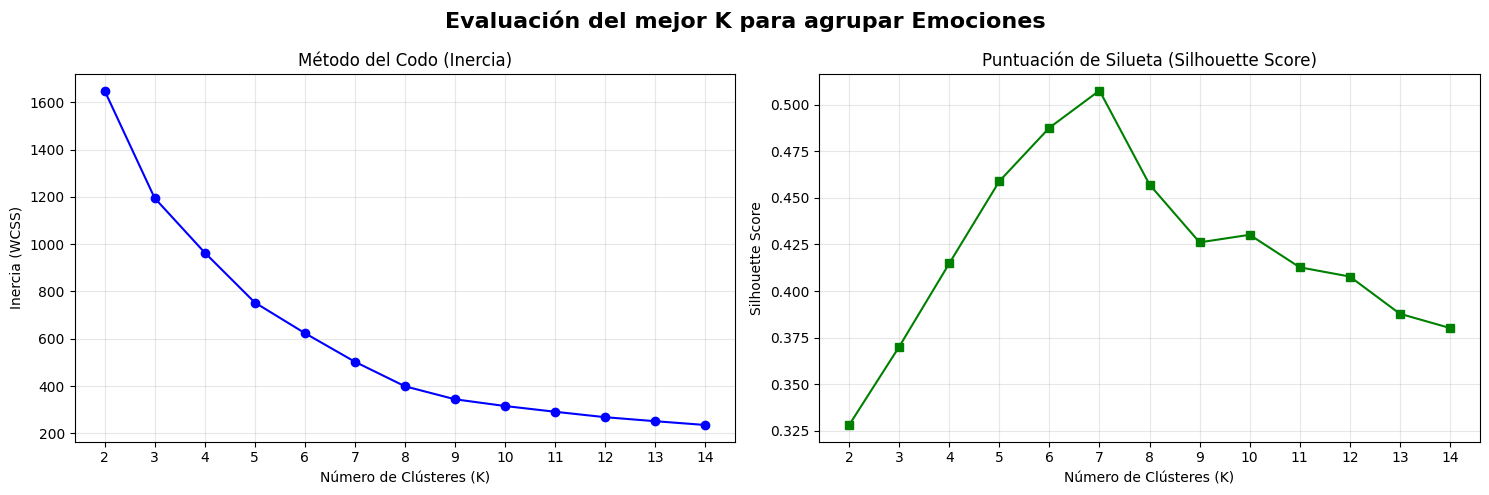

In [34]:
graficarKmeans(rango_k, inercias, siluetas)

**Entrenar modelo con el K óptimo**

Según las gráficas anteriores concluimos que es K=7


Entrenando K-Means final con K=7 en 7 dimensiones...


c:\Users\DELL\Documents\ML\Proyecto\env\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but PCA was fitted with feature names
  warnings.warn(


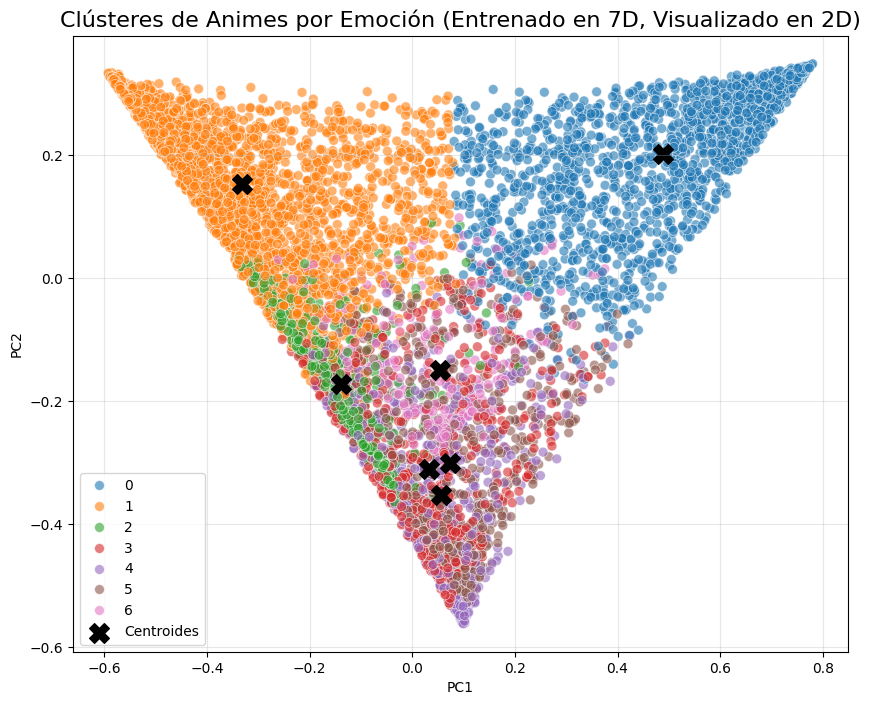

In [35]:
K_OPTIMO = 7

print(f"\nEntrenando K-Means final con K={K_OPTIMO} en 7 dimensiones...")
# 1. CAMBIO AQUÍ: Entrenamos K-Means usando los datos originales (X_scaled)
kmeans_final = KMeans(n_clusters=K_OPTIMO, init='k-means++', random_state=42, n_init=10)
etiquetas_finales = kmeans_final.fit_predict(X_scaled)


pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

df_pca = pd.DataFrame(data=X_pca, columns=['PC1', 'PC2'])
df_pca['Cluster'] = etiquetas_finales

# Dibujar clústers
plt.figure(figsize=(10, 8))

sns.scatterplot(
    x='PC1', y='PC2', hue='Cluster',
    palette='tab10', data=df_pca, alpha=0.6, s=50
)


# 2. CAMBIO AQUÍ: Transformamos los centroides de 7D a 2D para poder dibujarlos
centroides_7d = kmeans_final.cluster_centers_
centroides_2d = pca.transform(centroides_7d)

# Dibujamos usando los centroides ya convertidos a 2D
plt.scatter(centroides_2d[:, 0], centroides_2d[:, 1], c='black', s=200, marker='X', label='Centroides')

plt.title('Clústeres de Animes por Emoción (Entrenado en 7D, Visualizado en 2D)', fontsize=16)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# No olvides guardar las etiquetas en tu dataset original
df_animes_emociones['cluster_emocional'] = etiquetas_finales

**Guardar en el drive el Modelo**

In [37]:
# Guardar Modelo K-Means
# Creamos un nombre que incluya el K y la fecha
# fecha = datetime.now().strftime("%Y%m%d")
# nombre_modelo = f'kmeans_k{K_OPTIMO}_{fecha}.pkl'

#ruta_dinamica = f'/content/drive/MyDrive/ML/{nombre_modelo}'
nombre_modelo = f'kmeans_k{K_OPTIMO}.pkl'
joblib.dump(kmeans_final, nombre_modelo)
print(f"Modelo guardado en: {nombre_modelo}")

Modelo guardado en: kmeans_k7.pkl


### Porcentaje de Emociones por Clúster

**Agregar una columna al dataset, para mostrar a que clúster pertenece el ánime**

Esto con el modelo previamente guardado

In [38]:
kmeans = joblib.load(nombre_modelo)
df_animes_emociones['Cluster'] = kmeans.predict(X_scaled)

### ----

In [39]:
resumen_emociones = df_animes_emociones.groupby('Cluster')[['anger', 'disgust', 'fear', 'joy', 'neutral', 'sadness', 'surprise']].mean()
display(resumen_emociones)

,anger,disgust,fear,joy,neutral,sadness,surprise
Cluster,,,,,,,
0,0.058455,0.039983,0.697710,0.014029,0.121738,0.041025,0.027061
1,0.053013,0.056994,0.081491,0.062647,0.665799,0.041212,0.038844
2,0.020683,0.020112,0.025997,0.634269,0.240069,0.027794,0.031076
3,0.117090,0.552565,0.088014,0.015051,0.158755,0.053601,0.014924
4,0.045592,0.047440,0.081622,0.029191,0.134380,0.638912,0.022862
5,0.530612,0.131324,0.110857,0.012546,0.144524,0.054227,0.015911
6,0.038326,0.026171,0.102392,0.025366,0.129648,0.026935,0.651162


**Probar Modelo**

In [40]:
def getAnimeCluster(X_array, animes_input):
  result = kmeans.predict(X_array)
  anime_name_popularity = df_animes_emociones[df_animes_emociones['Cluster'] == result[0]]
  anime_name_popularity = anime_name_popularity[~anime_name_popularity['anime_id'].isin(animes_input)]
  anime_name_popularity = anime_name_popularity.drop(columns=['anime_id', 'fear', 'sadness', 'neutral', 'joy', 'anger', 'surprise', 'disgust'])
  anime_name_popularity = anime_name_popularity.sort_values(by='popularity_rank', ascending=True)
  return anime_name_popularity[['title', 'popularity_rank', 'Cluster']]

In [41]:
console = Console()
def mostrar_titulo(texto):
    console.print(Panel.fit(texto, style="white"))

# Función para mostrar un mensaje de error
def mostrar_error(texto):
    console.print(f"[bold red]Error:[/bold red] {texto}")

# Función para mostrar un mensaje de éxito
def mostrar_exito(texto):
    console.print(f"[bold green]Éxito:[/bold green] {texto}\n")

def mostrar_dataframe(df, titulo):
    console.print(Panel.fit(titulo, style="bold yellow"))
    console.print(tabulate(df, headers='keys', tablefmt='pretty', showindex=False))


In [43]:
df = df_animes_emociones
console = Console()
Nombres = pd.DataFrame()
animes_input = []
mostrar_titulo("Sistema de Recomendación de Animes")
console.print("Escribe los nombres de los animes que ya has visto, separados por comas. Escribe 'fin' cuando termines:", style="bold")

while True:

    nombre = input("Ingresa un nombre de anime, (Escribe 'fin' cuando termines): \n")
    if nombre.lower() == 'fin':
        break
    temp_list = nombre.strip().split(",")


    # Filtrar las filas correspondientes al nombre ingresado
    for item in temp_list:
      filtrado = df_animes_emociones[df_animes_emociones['title'] == item.strip()][['fear', 'sadness', 'neutral', 'joy', 'anger', 'surprise', 'disgust']]
      if filtrado.empty :
        mostrar_error(f"No se encontró el anime: {item}")

      else:
        #mostrar_exito(f"Anime agregado: {item}")
        Nombres = pd.concat([Nombres, filtrado], ignore_index=True)

        # Añadir al DataFrame de resultados
        anime_id = df_animes_emociones[df_animes_emociones['title'] == item.strip()]['anime_id'].iloc[0]
        animes_input.append(int(anime_id))

if Nombres.empty:
  mostrar_error("No se encontraron animes en tu lista.")

else:
  # Calcular los valores promedio de las columnas de emociones
  columnas_emociones = ['fear', 'sadness', 'neutral', 'joy', 'anger', 'surprise', 'disgust']
  promedios = Nombres[columnas_emociones].mean()
  # Crear un nuevo DataFrame
  user_emotion_mean = pd.DataFrame([promedios], columns=columnas_emociones)
  X_array = user_emotion_mean.values
  content_recomendation = getAnimeCluster(X_array, animes_input)


  final_recomendation = content_recomendation.drop_duplicates().sort_values('popularity_rank')
  mostrar_titulo("Recomendaciones Finales")
  mostrar_dataframe(final_recomendation[0:15], "Animes Recomendados")


╭────────────────────────────────────╮
│ Sistema de Recomendación de Animes │
╰────────────────────────────────────╯

Escribe los nombres de los animes que ya has visto, separados por comas. Escribe 'fin' cuando termines:

c:\Users\DELL\Documents\ML\Proyecto\env\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but KMeans was fitted with feature names
  warnings.warn(


╭─────────────────────────╮
│ Recomendaciones Finales │
╰─────────────────────────╯

╭─────────────────────╮
│ Animes Recomendados │
╰─────────────────────╯

+----------------------------------------+-----------------+---------+
|                 title                  | popularity_rank | Cluster |
+----------------------------------------+-----------------+---------+
|             Kimi no Na wa.             |       11        |    0    |
|      Shingeki no Kyojin Season 2       |       12        |    0    |
|      Shingeki no Kyojin Season 3       |       21        |    0    |
|    Boku no Hero Academia 3rd Season    |       25        |    0    |
|            Mirai Nikki (TV)            |       27        |    0    |
|        Boku dake ga Inai Machi         |       30        |    0    |
|   Shingeki no Kyojin Season 3 Part 2   |       31        |    0    |
|          Jujutsu Kaisen (TV)           |       32        |    0    |
|          Sword Art Online II           |       33        |    0    |
|             Ao no Exorcist             |       34        |    0    |
|             Mob Psycho 100             |       36        |    0    |
| Kono Subarashii Sekai ni Shukufuku wo! |       37        |    0    |
|               Haikyuu!!                |       38        |    0    |
|       Kiseijuu: Sei no Kakuritsu       |       41        |    0    |
|              Cowboy Bebop              |       42        |    0    |
+----------------------------------------+-----------------+---------+